# Lab 2: Classification Using KNN and RNN Algorithms
**Name:** Sowmya Cheruku  
**Course:** MSCS 634 – Advanced Big Data and Data Mining  
**University:** University of the Cumberlands  
**Instructor:** Satish Penmatsa  
**Assignment:** Lab 2 – KNN and Radius Neighbors on the Wine Dataset

## Step 1: Load and Prepare the Dataset
First I'll load the Wine dataset and take a look at what's in it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier

wine = load_wine()
X, y = wine.data, wine.target
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

print("Shape:", df.shape)
print("Classes:", wine.target_names)
df.head()

Shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [2]:
# feature summary and class distribution
display(df.describe().T[['mean','std','min','max']].round(2))
print("Missing values:", df.isnull().sum().sum())
print()
print(df['target'].value_counts().sort_index().rename(dict(enumerate(wine.target_names))))

,mean,std,min,max
alcohol,13.00,0.81,11.03,14.83
malic_acid,2.34,1.12,0.74,5.80
ash,2.37,0.27,1.36,3.23
alcalinity_of_ash,19.49,3.34,10.60,30.00
magnesium,99.74,14.28,70.00,162.00
total_phenols,2.30,0.63,0.98,3.88
flavanoids,2.03,1.00,0.34,5.08
nonflavanoid_phenols,0.36,0.12,0.13,0.66
proanthocyanins,1.59,0.57,0.41,3.58
color_intensity,5.06,2.32,1.28,13.00


Missing values: 0

target
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


**What I noticed:** The dataset has 178 samples, 13 numeric features and 3 classes (class_0: 59, class_1: 71, class_2: 48). The classes are fairly balanced and there are no missing values. The features are on very different scales, e.g. `proline` reaches into the 1000s while `hue` and `nonflavanoid_phenols` stay below 2. Since KNN and RNN both depend on distance, I expect this to matter later.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 142 | Test size: 36


## Step 2: K-Nearest Neighbors (KNN)
I'll try k = 1, 5, 11, 15 and 21, train on the training set, and record test accuracy.

In [4]:
k_values = [1, 5, 11, 15, 21]
knn_acc = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    knn_acc.append(acc)
    print(f"k = {k:>2}  accuracy = {acc:.4f}")

k =  1  accuracy = 0.7778
k =  5  accuracy = 0.7222
k = 11  accuracy = 0.7500
k = 15  accuracy = 0.7500
k = 21  accuracy = 0.7778


## Step 3: Radius Neighbors (RNN)
Radius values: 350, 400, 450, 500, 550, 600. I set `outlier_label='most_frequent'` so the model doesn't crash if a test point has no neighbors inside the radius.

In [5]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_acc = []
for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent')
    rnn.fit(X_train, y_train)
    acc = rnn.score(X_test, y_test)
    rnn_acc.append(acc)
    print(f"radius = {r}  accuracy = {acc:.4f}")

radius = 350  accuracy = 0.7500
radius = 400  accuracy = 0.7222
radius = 450  accuracy = 0.7222
radius = 500  accuracy = 0.7222
radius = 550  accuracy = 0.7222
radius = 600  accuracy = 0.7222


## Step 4: Visualize and Compare Results

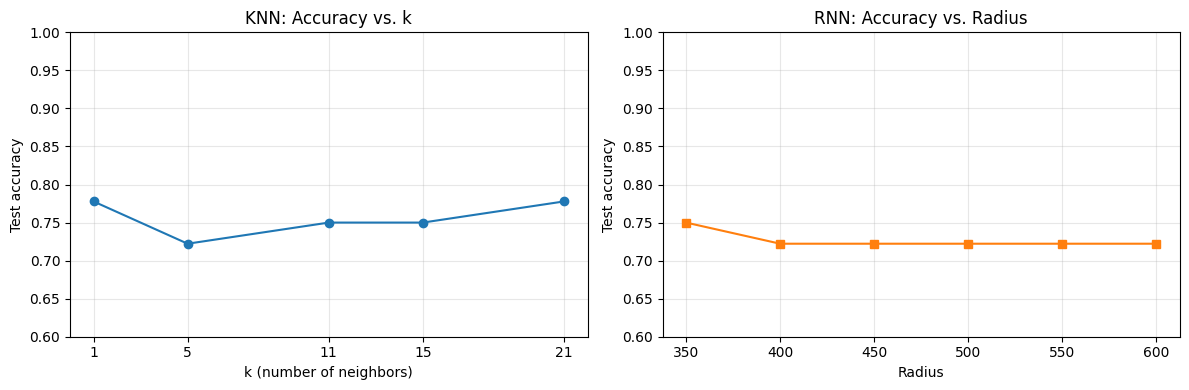

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_values, knn_acc, marker='o', color='tab:blue')
ax[0].set_title('KNN: Accuracy vs. k')
ax[0].set_xlabel('k (number of neighbors)')
ax[0].set_ylabel('Test accuracy')
ax[0].set_xticks(k_values)
ax[0].set_ylim(0.6, 1.0)
ax[0].grid(alpha=0.3)

ax[1].plot(radius_values, rnn_acc, marker='s', color='tab:orange')
ax[1].set_title('RNN: Accuracy vs. Radius')
ax[1].set_xlabel('Radius')
ax[1].set_ylabel('Test accuracy')
ax[1].set_xticks(radius_values)
ax[1].set_ylim(0.6, 1.0)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
summary = pd.DataFrame({'KNN k': k_values, 'KNN accuracy': knn_acc})
summary2 = pd.DataFrame({'RNN radius': radius_values, 'RNN accuracy': rnn_acc})
display(summary); display(summary2)
print("Best KNN:", max(knn_acc), "| Best RNN:", max(rnn_acc))

,KNN k,KNN accuracy
0,1,0.777778
1,5,0.722222
2,11,0.750000
3,15,0.750000
4,21,0.777778


,RNN radius,RNN accuracy
0,350,0.750000
1,400,0.722222
2,450,0.722222
3,500,0.722222
4,550,0.722222
5,600,0.722222


Best KNN: 0.7777777777777778 | Best RNN: 0.75


### Observations
- **KNN:** Accuracy stayed between about 72% and 78% and didn't improve as k got bigger. The best results (about 78%) were at k=1 and k=21, with dips at k=5, 11 and 15. The test set only has 36 samples, so each prediction is worth about 2.8%. I think these small ups and downs are mostly noise and not a real trend.
- **RNN:** Accuracy was 75% at radius 350, then dropped to about 72% from 400 on and stayed flat. With a large radius, almost every training point ends up inside the neighborhood, so the vote is basically the class mix of the whole training set and stops being useful.
- **Comparison:** KNN did a bit better than RNN (best 77.8% vs 75%) and was less sensitive to its parameter. Both were lower than I expected for this dataset.
- **Why accuracy is low:** My explanation is the feature scales. `proline` has a standard deviation of about 314 while most other features are below 1, so distances are mostly just proline and the other 12 features barely count. This also explains why the radius has to be so large (350-600), since the typical distance between points is around 300. I test this idea in the extra section below.

**When to prefer which:** KNN is the safer default because it always has k neighbors to vote with, even where data is sparse. RNN is a better fit when distance has a real meaning and every point within a fixed distance should count, or when I want to flag points that have no close neighbors as outliers. The downside is that the radius is harder to choose, since it depends completely on the feature scale.

## Extra: Does scaling fix it?
Quick check to back up my explanation above (not required by the lab).

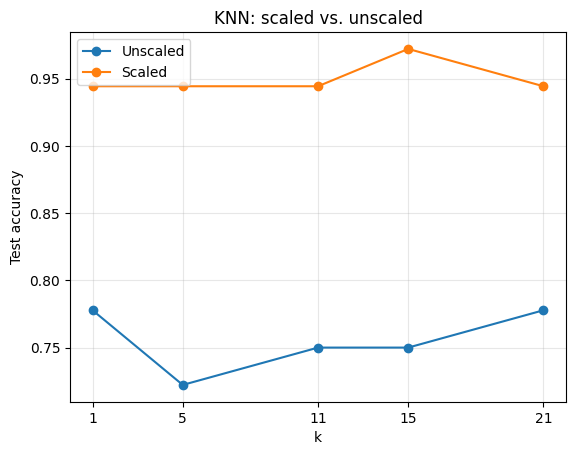

{1: np.float64(0.9444), 5: np.float64(0.9444), 11: np.float64(0.9444), 15: np.float64(0.9722), 21: np.float64(0.9444)}


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)

scaled_acc = []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k).fit(Xtr_s, y_train)
    scaled_acc.append(m.score(Xte_s, y_test))

plt.plot(k_values, knn_acc, marker='o', label='Unscaled')
plt.plot(k_values, scaled_acc, marker='o', label='Scaled')
plt.xlabel('k'); plt.ylabel('Test accuracy'); plt.title('KNN: scaled vs. unscaled')
plt.xticks(k_values); plt.legend(); plt.grid(alpha=0.3); plt.show()
print(dict(zip(k_values, np.round(scaled_acc, 4))))

After standardizing, KNN accuracy went up to about 94-97% for every k, so the unscaled features (mainly proline) really were hurting the distance-based models. If I did this on a real project, I would scale the features first.